STEP 1: DATA LOADING & PREPROCESSING
Upload Global_Pollution_Analysis.csv:


Saving Global_Pollution_Analysis_Processed.csv to Global_Pollution_Analysis_Processed.csv
Loaded 'Global_Pollution_Analysis_Processed.csv' -> shape (1000, 14)
Columns: ['country', 'year', 'air_pollution_index', 'water_pollution_index', 'soil_pollution_index', 'co2_emissions', 'industrial_waste_in_tons', 'energy_consumption_per_capita', 'renewable_energy_percentage', 'energy_recovery_gwh', 'pollution_severity', 'country_encoded', 'year_from_start', 'pollution_score']
Missing values before: 0
Missing values after : 0

STEP 2: FEATURE DERIVATION
energy_per_capita taken from existing column 'energy_consumption_per_capita'
Pollution indicators used for severity: ['air_pollution_index', 'water_pollution_index', 'soil_pollution_index', 'co2_emissions', 'industrial_waste_in_tons']
Features discretised into Low/Medium/High items: ['air_pollution_index', 'water_pollution_index', 'soil_pollution_index', 'co2_emissions', 'industrial_waste_in_tons', 'renewable_energy_percentage', 'energy_recovery_g

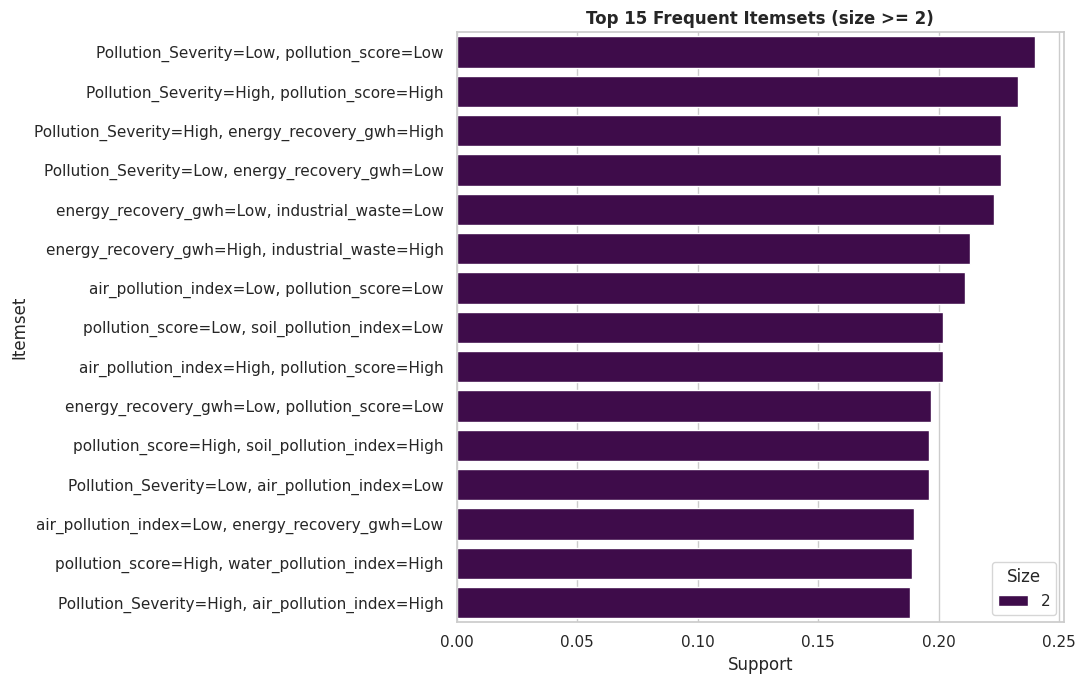

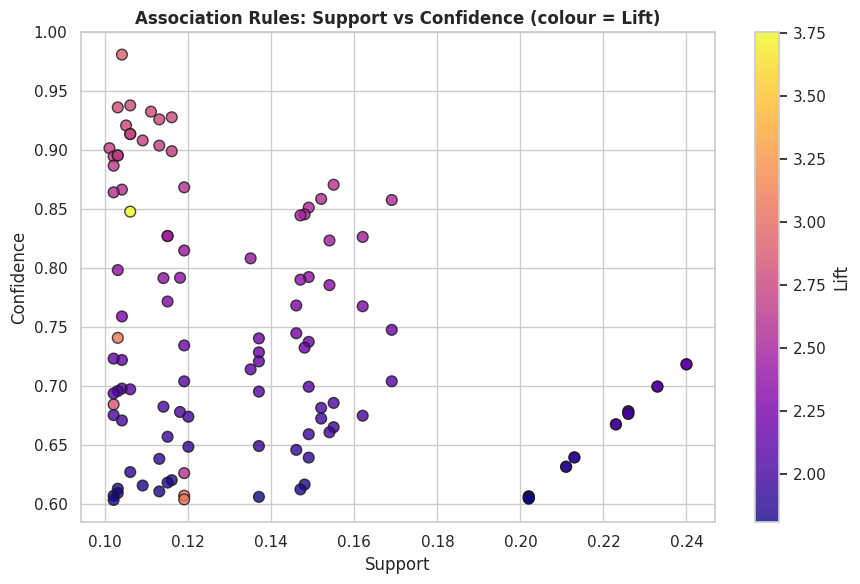

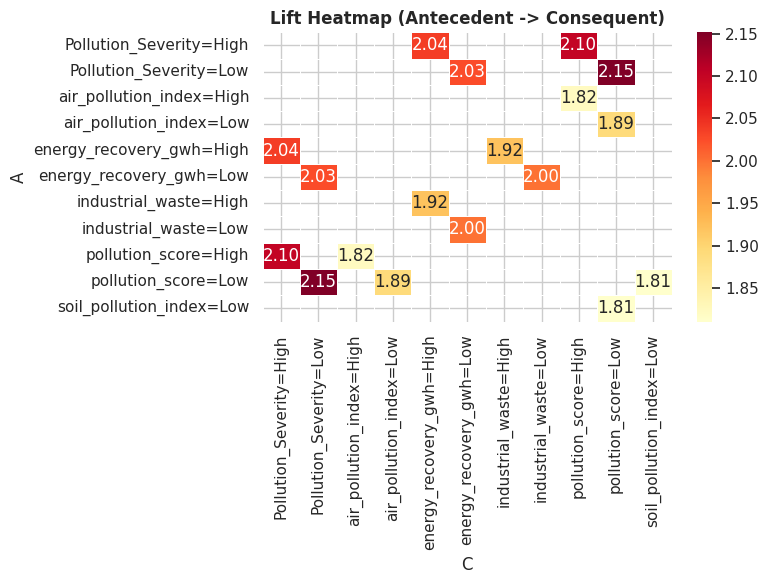

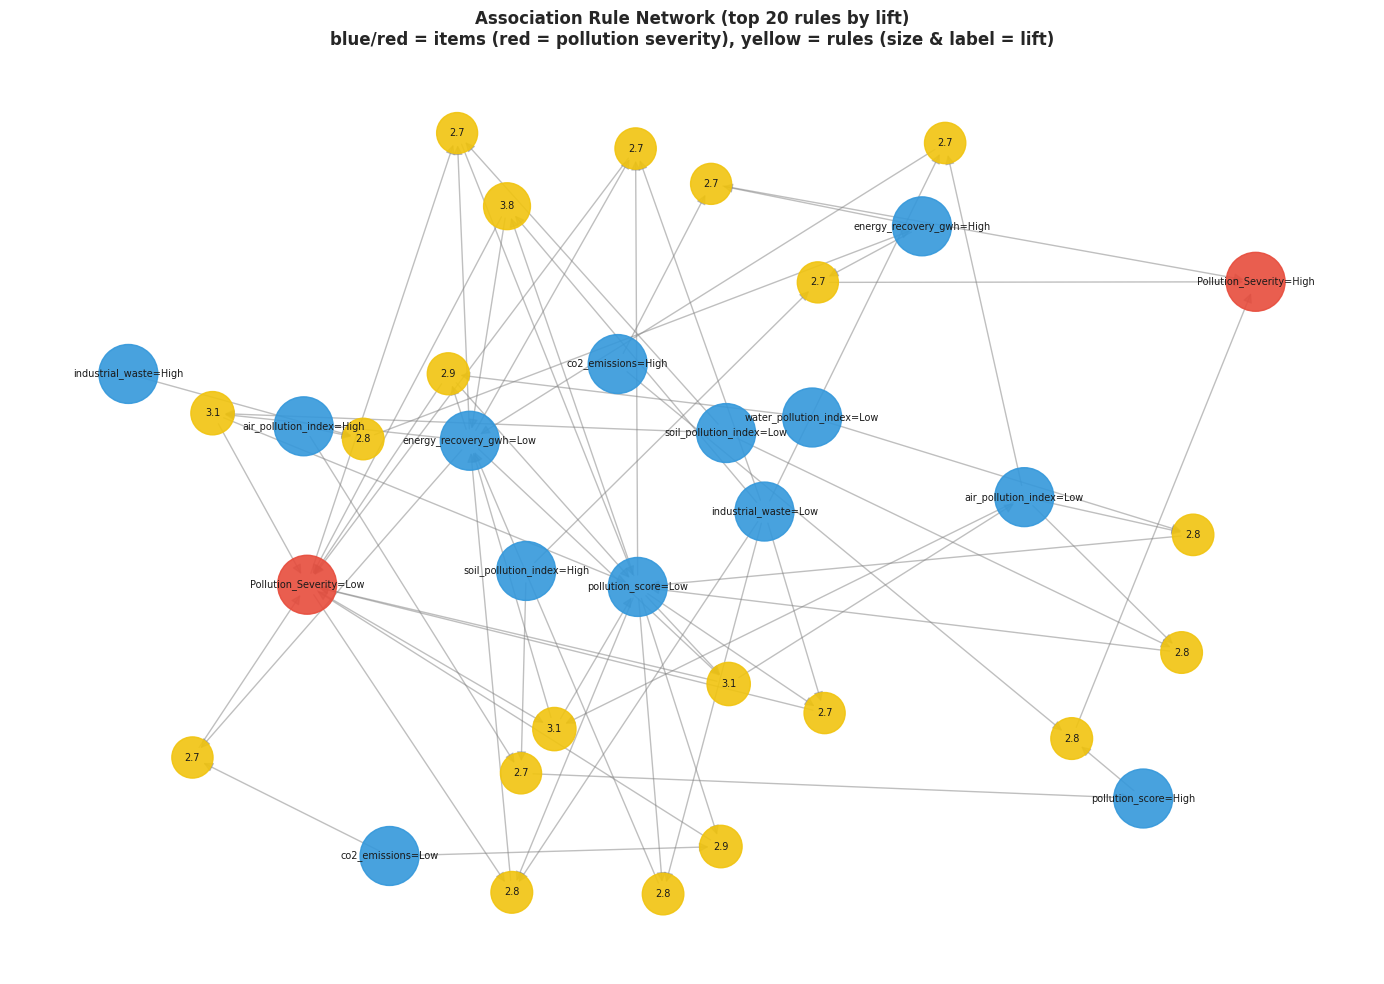

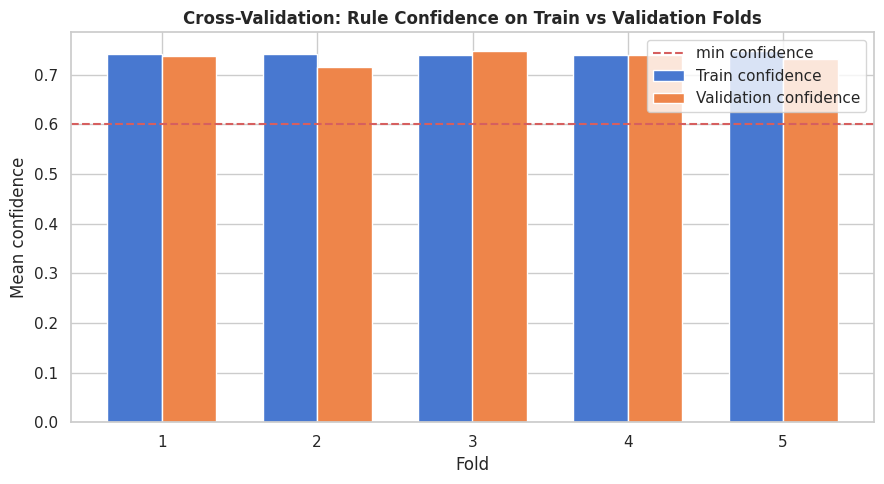


Done. Rules saved to 'association_rules_full.csv'.


In [ ]:
# ==============================================================================
# ASSOCIATION RULE MINING ON GLOBAL POLLUTION DATA (APRIORI FROM SCRATCH)
#   1. Load & preprocess Global_Pollution_Analysis.csv
#   2. Derive energy consumption per capita + pollution severity (Low/Medium/High)
#   3. Apriori frequent itemset generation (own implementation)
#   4. Association rule mining (min support / min confidence)
#   5. Rule evaluation: support, confidence, lift (+ leverage, conviction)
#   6. Validation: train/test split + 5-fold cross-validation of rules
#   7. Visualizations: itemsets, support-confidence plot, lift heatmap, rule network
# ==============================================================================

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from itertools import combinations
from sklearn.model_selection import train_test_split, KFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
np.random.seed(42)

# ----------------------------- PARAMETERS ------------------------------------
MIN_SUPPORT = 0.10      # minimum support for frequent itemsets
MIN_CONF    = 0.60      # minimum confidence for rules
MIN_LIFT    = 1.0       # keep only positively correlated rules
N_FOLDS     = 5
TOP_N_NET   = 20        # rules shown in network graph

# ==============================================================================
# 1. LOAD & PREPROCESS
# ==============================================================================
print("=" * 80, "\nSTEP 1: DATA LOADING & PREPROCESSING\n", "=" * 80, sep="")

csv_path = "Global_Pollution_Analysis.csv"
if not os.path.exists(csv_path):
    try:
        from google.colab import files
        print("Upload Global_Pollution_Analysis.csv:")
        up = files.upload()
        if up:
            csv_path = list(up.keys())[0]
    except Exception:
        pass

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded '{csv_path}' -> shape {df.shape}")
else:
    print("File not found -> generating synthetic stand-in dataset.")
    n = 1000
    pop = np.random.uniform(1, 1400, n)
    df = pd.DataFrame({
        "Country": np.random.choice(list("ABCDEFGHIJ"), n),
        "Year": np.random.choice(range(2000, 2024), n),
        "Air_Pollution_Index": np.random.uniform(20, 300, n),
        "Water_Pollution_Index": np.random.uniform(10, 250, n),
        "Soil_Pollution_Index": np.random.uniform(10, 200, n),
        "CO2_Emissions": np.random.uniform(1, 40, n),
        "Industrial_Waste": np.random.uniform(1e3, 1e6, n),
        "Renewable_Energy": np.random.uniform(0, 80, n),
        "Population": pop,
        "Energy_Consumption": pop * np.random.uniform(1, 30, n),
        "GDP_Per_Capita": np.random.uniform(500, 80000, n),
    })

# Normalise column names
df.columns = [re.sub(r"[^a-z0-9]+", "_", c.strip().lower()).strip("_") for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)
print("Columns:", df.columns.tolist())

# Convert object columns that are really numeric
for c in df.columns:
    if df[c].dtype == object:
        conv = pd.to_numeric(df[c].astype(str).str.replace(r"[^\d.\-eE]", "", regex=True), errors="coerce")
        if conv.notna().mean() > 0.9:
            df[c] = conv

num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Missing values before:", int(df[num_cols].isna().sum().sum()))
df[num_cols] = df[num_cols].fillna(df[num_cols].median())          # median imputation
for c in df.select_dtypes(exclude=np.number).columns:
    df[c] = df[c].fillna(df[c].mode()[0])
print("Missing values after :", int(df[num_cols].isna().sum().sum()))

# ==============================================================================
# 2. DERIVED FEATURES: ENERGY PER CAPITA & POLLUTION SEVERITY
# ==============================================================================
print("\n" + "=" * 80, "\nSTEP 2: FEATURE DERIVATION\n", "=" * 80, sep="")

def find(patterns, cols, exclude=None):
    for p in patterns:
        for c in cols:
            if re.search(p, c) and not (exclude and re.search(exclude, c)):
                return c
    return None

col_pop     = find([r"populat"], num_cols)
col_energy  = find([r"energy.*consum"], num_cols, exclude=r"per_capita")
col_epc_raw = find([r"energy.*consum.*per_capita", r"energy.*per_capita"], num_cols)

if col_energy and col_pop:
    df["energy_per_capita"] = df[col_energy] / df[col_pop].replace(0, np.nan)
    df["energy_per_capita"] = df["energy_per_capita"].fillna(df["energy_per_capita"].median())
    print(f"energy_per_capita = {col_energy} / {col_pop}")
elif col_epc_raw:
    df["energy_per_capita"] = df[col_epc_raw]
    print(f"energy_per_capita taken from existing column '{col_epc_raw}'")
else:
    raise ValueError("No energy consumption column found - check printed column names.")

# Composite pollution severity index = mean of min-max scaled pollution indicators
pollution_patterns = [r"air.*pollution", r"water.*pollution", r"soil.*pollution",
                      r"co2", r"industrial.*waste"]
pollution_cols = [find([p], num_cols) for p in pollution_patterns]
pollution_cols = [c for c in dict.fromkeys(pollution_cols) if c]
if not pollution_cols:
    raise ValueError("No pollution indicator columns detected.")
print("Pollution indicators used for severity:", pollution_cols)

scaled = (df[pollution_cols] - df[pollution_cols].min()) / (df[pollution_cols].max() - df[pollution_cols].min() + 1e-12)
df["pollution_index"] = scaled.mean(axis=1)

# Features to turn into items (exclude identifiers/time)
exclude_items = {"year", "pollution_index"}
if col_energy: exclude_items.add(col_energy)       # replaced by energy_per_capita
if col_epc_raw: exclude_items.add(col_epc_raw)
bin_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude_items]
print("Features discretised into Low/Medium/High items:", bin_cols)

# Tercile-based severity categories (shown on full data for reporting)
df["pollution_severity"] = pd.qcut(df["pollution_index"].rank(method="first"), 3,
                                   labels=["Low", "Medium", "High"])
print("\nPollution severity distribution:\n", df["pollution_severity"].value_counts())
print(df[["energy_per_capita", "pollution_index", "pollution_severity"]].head())

num_df = df[bin_cols + ["pollution_index"]].copy()    # numeric table used for binning

def short(c):
    return c.split("_in_")[0][:24]

LEVELS = ["Low", "Medium", "High"]

def fit_edges(train_df):
    """Tercile cut-points learned on training data only (no leakage)."""
    return {c: np.quantile(train_df[c], [1/3, 2/3]) for c in train_df.columns}

def to_transactions(data, edges):
    """Turn numeric rows into a boolean one-hot transaction matrix."""
    out = {}
    for c, (e1, e2) in edges.items():
        x = data[c].values
        lvl = np.where(x <= e1, "Low", np.where(x <= e2, "Medium", "High"))
        name = "Pollution_Severity" if c == "pollution_index" else short(c)
        for L in LEVELS:
            out[f"{name}={L}"] = (lvl == L)
    return pd.DataFrame(out, index=data.index)

# ==============================================================================
# 3. APRIORI (FROM SCRATCH)
# ==============================================================================
def apriori(onehot, min_support):
    items = onehot.columns.tolist()
    M = onehot.values
    n = len(M)
    freq = {}

    # L1
    current = []
    for i, it in enumerate(items):
        s = M[:, i].mean()
        if s >= min_support:
            freq[frozenset([it])] = s
            current.append((i,))
    k = 2
    while current:
        cur_set = set(current)
        candidates = []
        for a, b in combinations(current, 2):                 # join step
            if a[:-1] == b[:-1]:
                cand = a + (b[-1],)
                if all(sub in cur_set for sub in combinations(cand, k - 1)):   # prune step
                    candidates.append(cand)
        nxt = []
        for cand in candidates:                               # support counting
            s = M[:, list(cand)].all(axis=1).mean()
            if s >= min_support:
                freq[frozenset(items[i] for i in cand)] = s
                nxt.append(cand)
        current, k = nxt, k + 1
    return freq

# ==============================================================================
# 4. RULE GENERATION
# ==============================================================================
def generate_rules(freq, min_conf, min_lift=0.0):
    rows = []
    for itemset, sup in freq.items():
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for ante in combinations(itemset, r):
                ante = frozenset(ante)
                cons = itemset - ante
                s_a, s_c = freq[ante], freq[cons]            # guaranteed by Apriori property
                conf = sup / s_a
                lift = conf / s_c
                if conf >= min_conf and lift >= min_lift:
                    rows.append({
                        "antecedents": ante, "consequents": cons,
                        "support": sup, "confidence": conf, "lift": lift,
                        "leverage": sup - s_a * s_c,
                        "conviction": (1 - s_c) / (1 - conf) if conf < 1 else np.inf,
                    })
    rules = pd.DataFrame(rows)
    if rules.empty:
        return pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence",
                                     "lift", "leverage", "conviction"])
    return rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

def fmt(s):
    return ", ".join(sorted(s))

# ----- Mine on the full dataset (descriptive analysis) -----
print("\n" + "=" * 80, "\nSTEP 3-5: APRIORI, RULE MINING & EVALUATION (full data)\n", "=" * 80, sep="")
edges_full = fit_edges(num_df)
oh_full = to_transactions(num_df, edges_full)
print(f"Transactions: {oh_full.shape[0]} | Items: {oh_full.shape[1]}")

freq_full = apriori(oh_full, MIN_SUPPORT)
print(f"Frequent itemsets (min_support={MIN_SUPPORT}): {len(freq_full)}")
sizes = pd.Series([len(k) for k in freq_full]).value_counts().sort_index()
print("Itemsets by size:\n", sizes.to_string())

rules_full = generate_rules(freq_full, MIN_CONF, MIN_LIFT)
print(f"\nRules (conf>={MIN_CONF}, lift>={MIN_LIFT}): {len(rules_full)}")

show = rules_full.copy()
show["antecedents"] = show["antecedents"].map(fmt)
show["consequents"] = show["consequents"].map(fmt)
pd.set_option("display.width", 200, "display.max_colwidth", 60)
print("\nTop 15 rules by lift:")
print(show.head(15).round(3).to_string(index=False))

sev = rules_full[rules_full["consequents"].map(lambda s: "Pollution_Severity=High" in s)]
print(f"\nRules predicting Pollution_Severity=High: {len(sev)}")
if len(sev):
    t = sev.copy(); t["antecedents"] = t["antecedents"].map(fmt); t["consequents"] = t["consequents"].map(fmt)
    print(t.head(10).round(3).to_string(index=False))

show.to_csv("association_rules_full.csv", index=False)

# ==============================================================================
# 6. VALIDATION: TRAIN/TEST SPLIT + K-FOLD CROSS-VALIDATION
# ==============================================================================
def evaluate_rules(rules, onehot):
    """Recompute support/confidence/lift of already-mined rules on unseen data."""
    out = []
    for _, r in rules.iterrows():
        a = onehot[list(r["antecedents"])].all(axis=1).values
        c = onehot[list(r["consequents"])].all(axis=1).values
        s_a, s_c, s_ac = a.mean(), c.mean(), (a & c).mean()
        conf = s_ac / s_a if s_a > 0 else np.nan
        lift = conf / s_c if (s_c > 0 and not np.isnan(conf)) else np.nan
        out.append((s_ac, conf, lift))
    return pd.DataFrame(out, columns=["test_support", "test_confidence", "test_lift"])

print("\n" + "=" * 80, "\nSTEP 6: TRAIN/TEST VALIDATION OF RULES\n", "=" * 80, sep="")
tr_idx, te_idx = train_test_split(num_df.index, test_size=0.20, random_state=42, shuffle=True)
edges_tr = fit_edges(num_df.loc[tr_idx])
oh_tr = to_transactions(num_df.loc[tr_idx], edges_tr)
oh_te = to_transactions(num_df.loc[te_idx], edges_tr)

rules_tr = generate_rules(apriori(oh_tr, MIN_SUPPORT), MIN_CONF, MIN_LIFT)
ev = evaluate_rules(rules_tr, oh_te)
val = pd.concat([rules_tr[["antecedents", "consequents", "support", "confidence", "lift"]]
                 .rename(columns={"support": "train_support", "confidence": "train_confidence",
                                  "lift": "train_lift"}), ev], axis=1)
val["holds_on_test"] = (val["test_confidence"] >= MIN_CONF) & (val["test_lift"] > 1)

print(f"Rules mined on train ({len(tr_idx)} rows): {len(val)}")
if len(val):
    print(f"Mean confidence  train: {val.train_confidence.mean():.3f} | test: {val.test_confidence.mean():.3f}")
    print(f"Mean lift        train: {val.train_lift.mean():.3f} | test: {val.test_lift.mean():.3f}")
    print(f"Rules still valid on test set (conf>={MIN_CONF} & lift>1): "
          f"{val.holds_on_test.sum()}/{len(val)} ({100*val.holds_on_test.mean():.1f}%)")

print(f"\n--- {N_FOLDS}-Fold Cross-Validation ---")
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_rows, rule_counter = [], {}
for fold, (a_idx, b_idx) in enumerate(kf.split(num_df), 1):
    tr, te = num_df.iloc[a_idx], num_df.iloc[b_idx]
    edges = fit_edges(tr)
    o_tr, o_te = to_transactions(tr, edges), to_transactions(te, edges)
    r = generate_rules(apriori(o_tr, MIN_SUPPORT), MIN_CONF, MIN_LIFT)
    if r.empty:
        cv_rows.append([fold, 0, np.nan, np.nan, np.nan, np.nan]); continue
    e = evaluate_rules(r, o_te)
    ok = ((e.test_confidence >= MIN_CONF) & (e.test_lift > 1))
    cv_rows.append([fold, len(r), r.confidence.mean(), e.test_confidence.mean(),
                    e.test_lift.mean(), ok.mean()])
    for a_, c_ in zip(r["antecedents"], r["consequents"]):
        rule_counter[(a_, c_)] = rule_counter.get((a_, c_), 0) + 1

cv_df = pd.DataFrame(cv_rows, columns=["Fold", "N_Rules", "Train_Conf", "Val_Conf",
                                       "Val_Lift", "Validity_Rate"])
print(cv_df.round(3).to_string(index=False))
print("\nCV mean:\n", cv_df.drop(columns="Fold").mean().round(3).to_string())

stable = [(fmt(a), fmt(c), n) for (a, c), n in rule_counter.items() if n == N_FOLDS]
print(f"\nRules found in ALL {N_FOLDS} folds (stable rules): {len(stable)}")
for a, c, _ in stable[:10]:
    print(f"  {{{a}}} -> {{{c}}}")

# ==============================================================================
# 7. VISUALIZATIONS
# ==============================================================================
print("\n" + "=" * 80, "\nSTEP 7: VISUALIZATIONS\n", "=" * 80, sep="")

# 7a. Top frequent itemsets
fi = pd.DataFrame([(fmt(k), v, len(k)) for k, v in freq_full.items() if len(k) >= 2],
                  columns=["Itemset", "Support", "Size"]).sort_values("Support", ascending=False).head(15)
if len(fi):
    plt.figure(figsize=(11, 7))
    sns.barplot(data=fi, x="Support", y="Itemset", hue="Size", dodge=False, palette="viridis")
    plt.title("Top 15 Frequent Itemsets (size >= 2)", fontweight="bold")
    plt.tight_layout(); plt.show()

if len(rules_full):
    # 7b. Support vs confidence coloured by lift
    plt.figure(figsize=(9, 6))
    sc = plt.scatter(rules_full.support, rules_full.confidence, c=rules_full.lift,
                     cmap="plasma", s=60, edgecolor="k", alpha=0.8)
    plt.colorbar(sc, label="Lift")
    plt.xlabel("Support"); plt.ylabel("Confidence")
    plt.title("Association Rules: Support vs Confidence (colour = Lift)", fontweight="bold")
    plt.tight_layout(); plt.show()

    # 7c. Lift heatmap for single-item -> single-item rules
    one = rules_full[(rules_full.antecedents.map(len) == 1) & (rules_full.consequents.map(len) == 1)].copy()
    if len(one):
        one["A"] = one.antecedents.map(fmt); one["C"] = one.consequents.map(fmt)
        piv = one.pivot_table(index="A", columns="C", values="lift")
        plt.figure(figsize=(max(8, 0.6 * piv.shape[1]), max(6, 0.45 * piv.shape[0])))
        sns.heatmap(piv, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
        plt.title("Lift Heatmap (Antecedent -> Consequent)", fontweight="bold")
        plt.tight_layout(); plt.show()

    # 7d. Association rule network graph
    top = rules_full.head(TOP_N_NET)
    G = nx.DiGraph()
    for i, r in top.iterrows():
        rn = f"R{i}"
        G.add_node(rn, kind="rule", lift=r["lift"])
        for a in r["antecedents"]:
            G.add_node(a, kind="item"); G.add_edge(a, rn)
        for c in r["consequents"]:
            G.add_node(c, kind="item"); G.add_edge(rn, c)
    pos = nx.spring_layout(G, k=0.9, seed=42)
    items_ = [n for n, d in G.nodes(data=True) if d["kind"] == "item"]
    rules_ = [n for n, d in G.nodes(data=True) if d["kind"] == "rule"]
    item_col = ["#e74c3c" if "Pollution_Severity" in n else "#3498db" for n in items_]
    plt.figure(figsize=(14, 10))
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=14, alpha=0.5, edge_color="gray")
    nx.draw_networkx_nodes(G, pos, nodelist=items_, node_color=item_col, node_size=1800, alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=rules_, node_color="#f1c40f",
                           node_size=[200 + 250 * G.nodes[n]["lift"] for n in rules_], alpha=0.9)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in items_}, font_size=7)
    nx.draw_networkx_labels(G, pos, labels={n: f"{G.nodes[n]['lift']:.1f}" for n in rules_}, font_size=7)
    plt.title(f"Association Rule Network (top {len(top)} rules by lift)\n"
              "blue/red = items (red = pollution severity), yellow = rules (size & label = lift)",
              fontweight="bold")
    plt.axis("off"); plt.tight_layout(); plt.show()

# 7e. CV results
plt.figure(figsize=(9, 5))
cv_plot = cv_df.dropna()
if len(cv_plot):
    x = np.arange(len(cv_plot)); w = 0.35
    plt.bar(x - w/2, cv_plot.Train_Conf, w, label="Train confidence")
    plt.bar(x + w/2, cv_plot.Val_Conf, w, label="Validation confidence")
    plt.xticks(x, cv_plot.Fold); plt.xlabel("Fold"); plt.ylabel("Mean confidence")
    plt.axhline(MIN_CONF, color="r", ls="--", label="min confidence")
    plt.title("Cross-Validation: Rule Confidence on Train vs Validation Folds", fontweight="bold")
    plt.legend(); plt.tight_layout(); plt.show()

print("\nDone. Rules saved to 'association_rules_full.csv'.")

PHASE 2: TRAINING BASELINE SVR MODEL
Baseline SVR Performance (Test Set):
Mean Absolute Error (MAE) : 8.0465
Mean Squared Error (MSE)  : 240.7643
Root Mean Squared Error   : 15.5166
R-squared (R2) Score      : 0.0148


PHASE 3: HYPERPARAMETER TUNING VIA GRID SEARCH
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Hyperparameters Found:
{'C': 1000, 'epsilon': 0.5, 'gamma': 1}

Optimized SVR Performance (Test Set):
Mean Absolute Error (MAE) : 3.4985
Mean Squared Error (MSE)  : 139.3054
Root Mean Squared Error   : 11.8028
R-squared (R2) Score      : 0.4300


PHASE 4: FEATURE IMPORTANCE
Feature Importances sorted by Mean Decrease in Performance:


,Feature,Importance_Mean,Importance_Std
0,forests_2000,9.063550,1.639624
1,forests_2020,6.765903,1.800675
2,iso3c_encoded,-0.000964,0.013477


ValueError: 'xerr' (shape: (3,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (1,))

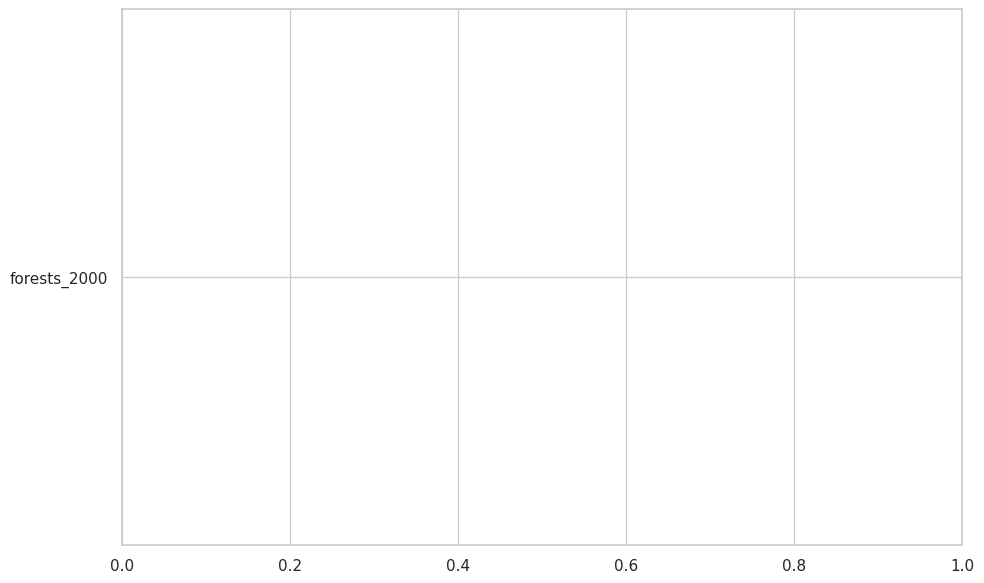